In [2]:
# %% [markdown]
# # Lead Quality Analysis — Validation Notebook
#
# This script reproduces and validates every statistic used in the Lead Quality
# Analysis report, organized around the three case-study questions:
#
# 1. Is there a lead-quality trend over time, and is it statistically significant?
# 2. What drives lead quality (segments)?
# 3. Can lead quality realistically move from 8.0% to 9.6%?
#
# Cells are marked with `# %%` so this file opens as a notebook in Jupyter
# (via Jupytext), VS Code, or Spyder — run top to bottom.
#
# Install once if needed:
#   pip install pandas numpy scipy statsmodels openpyxl xlrd matplotlib --break-system-packages

# %%
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# Shared color palette / style for every chart below
NAVY, TEAL, ORANGE, GRAY, GOLD = "#1f3a5f", "#2a9d8f", "#e76f51", "#bdbdbd", "#e9c46a"
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#888888",
})

# >>> EDIT THIS PATH if your file lives somewhere else <<<
DATA_PATH = "Analyst_case_study_dataset_1_(1).xls"

df = pd.read_excel(DATA_PATH)
df["LeadCreated"] = pd.to_datetime(df["LeadCreated"])
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head()

Loaded 3,021 rows, 24 columns


,LeadCreated,FirstName,Email,VendorLeadID,CallStatus,WidgetName,PublisherZoneName,PublisherCampaignName,AddressScore,PhoneScore,AdvertiserCampaignName,State,DebtLevel,IP Address,Partner,ReferralDomain,MarketingCampaign,AdGroup,Keyword,SearchQuery,ReferralURL,ReferralURL Parameters,LandingPageURL,Landing Page URL Parameters
0,2009-07-01 01:24:29.563,Dorinda,kanani@sandwichisles.net,FDF81FDA-A649-437B-B99C-FDDE74F7971B,NaN,w-302252-DebtReduction1-1DC-CreditSolutions,TopLeft-302252,DebtReductionInc,NaN,5.0,creditsolutions-branded-shortform,HI,30001-50000,NaN,google,www.google.com,Debt Holding Tank,Holding Tank - Debt,Debt specialists,debt specialists,http://www.google.com/search,sourceid=navclient&aq=1&oq=debt sp&ie=UTF-8&rl...,http://www.debtreductioninc.com/index8.html,utm_source=google&utm_medium=CPC&utm_content=H...
1,2009-04-13 15:27:35.990,Presetta,clerk2@ustconline.net,4190ACB7-5026-416C-B987-ED8AD427D5E6,NaN,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,AL,90000-100000,NaN,AdKnowledge,NaN,Financial Services,Consolidate,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...
2,2009-04-21 07:22:59.000,Gina,wagoner_gina@yahoo.com,hFg80jf_R0CRN55hdhWILw,Unable to contact - Bad Contact Information,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,NY,20001-30000,NaN,AdKnowledge,us.mc582.mail.yahoo.com,Financial Services,Consolidate,NaN,NaN,http://us.mc582.mail.yahoo.com/mc/showMessage,&fid=Inbox&sort=date&order=down&startMid=0&.ra...,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...
3,2009-08-03 19:39:02.000,Kari,usa4ley@yahoo.com,jB01QgYZxkWArI9jWxuufw,Contacted - Doesn't Qualify,w-302252-DebtReduction1-1DC-white,TopLeft-302252,DebtReductionInc,5.0,3.0,Debt Settlement1 Master,WA,20001-30000,NaN,Google,norwich.kijiji.com,DebtReductionInc,Lower Payments,NaN,NaN,http://norwich.kijiji.com/c-Cars-vehicles-Cars...,NaN,http://www.debtreductioninc.com/index12.html,utm_source=Google&utm_medium=cpc&utm_campaign=...
4,2009-04-13 10:18:37.490,Stephanie,sr1lambert@embarqmail.com,D5B32074-458E-40EC-B185-1FEF20AC626D,NaN,w-300250-DebtReduction1-1DC-BlueMeter,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,TX,More_than_100000,NaN,Google,NaN,DebtReductionInc,Debt Reduction,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=Google&utm_medium=cpc&utm_campaign=...


In [3]:


# %% [markdown]
# ## 0. Categorize CallStatus into the four groups defined in the assignment
#
# - **Closed** — became a customer (the advertiser's bottom-line success metric)
# - **Good-NotClosed** — EP Sent / EP Received / EP Confirmed (advertiser-defined "good" signal, short of closing)
# - **Bad** — Unable to contact / Invalid Profile / Doesn't Qualify
# - **Unknown** — no CallStatus recorded yet (still pending / unresolved)

# %%
GOOD_NOT_CLOSED = ["EP Sent", "EP Received", "EP Confirmed"]
BAD = [
    "Unable to contact - Bad Contact Information",
    "Contacted - Invalid Profile",
    "Contacted - Doesn't Qualify",
]


def categorize(status):
    if status == "Closed":
        return "Closed"
    if status in GOOD_NOT_CLOSED:
        return "Good-NotClosed"
    if status in BAD:
        return "Bad"
    return "Unknown"  # includes NaN


df["Category"] = df["CallStatus"].apply(categorize)
df["IsResolved"] = (df["Category"] != "Unknown").astype(int)
df["IsGood"] = df["Category"].isin(["Closed", "Good-NotClosed"]).astype(int)
df["IsClosed"] = (df["Category"] == "Closed").astype(int)

print(df["Category"].value_counts())
print()
print(df["Category"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

# %% [markdown]
# ### Sanity check: overall Closed rate should match the assignment's stated 8.0% baseline

# %%
overall_closed_rate = df["IsClosed"].mean() * 100
print(f"Overall Closed rate: {overall_closed_rate:.2f}%  (n={len(df):,})")
assert 7.5 < overall_closed_rate < 8.5, "Closed rate is off from the expected ~8.0% baseline — check categorization."
print("Matches the assignment's 8.0% baseline. The 9.6% target = +20% relative lift on this metric.")


Unknown           2140
Bad                488
Closed             245
Good-NotClosed     148
Name: Category, dtype: int64

Unknown           70.8%
Bad               16.2%
Closed             8.1%
Good-NotClosed     4.9%
Name: Category, dtype: object
Overall Closed rate: 8.11%  (n=3,021)
Matches the assignment's 8.0% baseline. The 9.6% target = +20% relative lift on this metric.


In [4]:

# %% [markdown]
# ---
# ## Question 1 — Is there a statistically significant lead-quality trend over time?
#
# **Caveat first:** ~71% of leads have no final status yet ("Unknown" / pending).
# A lead can sit in this state indefinitely, and leads created later in the
# window have had less calendar time to resolve. So raw month-over-month
# Closed rates can look artificially worse for recent months. We look at the
# data both ways below.

# %%
df["Month"] = df["LeadCreated"].dt.to_period("M").astype(str)
MONTH_ORDER = sorted(df["Month"].unique())

# %% [markdown]
# ### 1.1 Raw view — full category mix by month (shows the censoring problem directly)

# %%
raw_mix = pd.crosstab(df["Month"], df["Category"], normalize="index").loc[MONTH_ORDER] * 100
raw_mix = raw_mix[["Closed", "Good-NotClosed", "Bad", "Unknown"]].round(1)
print(raw_mix)

# %% [markdown]
# **Visualization:** stacked bars showing the full outcome mix by month —
# the gray "Unknown" block makes the censoring problem visible at a glance.


Category  Closed  Good-NotClosed   Bad  Unknown
Month                                          
2009-04     10.8             4.4  11.0     73.7
2009-05      6.4             3.8   9.8     80.0
2009-06     10.3             3.8  23.2     62.7
2009-07      6.2             3.0  20.7     70.1
2009-08      9.4             4.8  15.3     70.5
2009-09      4.4            12.5  16.3     66.9


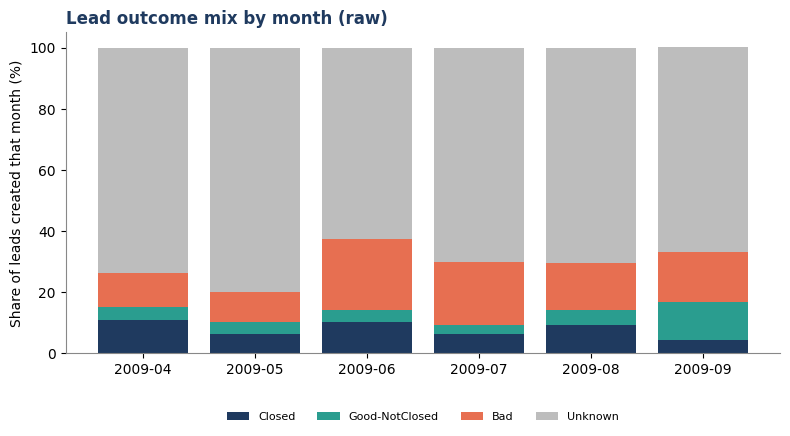

Resolved leads: 881 of 3,021 (29.2%)
           n  good  closed  good_rate_%  closed_rate_%
Month                                                 
2009-04  136    79      56         58.1           41.2
2009-05  116    59      37         50.9           31.9
2009-06  227    86      63         37.9           27.8
2009-07  159    49      33         30.8           20.8
2009-08  129    62      41         48.1           31.8
2009-09  114    58      15         50.9           13.2


In [5]:
# %%
fig, ax = plt.subplots()
bottom = np.zeros(len(raw_mix))
colors = {"Closed": NAVY, "Good-NotClosed": TEAL, "Bad": ORANGE, "Unknown": GRAY}
for col in ["Closed", "Good-NotClosed", "Bad", "Unknown"]:
    ax.bar(raw_mix.index, raw_mix[col], bottom=bottom, label=col, color=colors[col])
    bottom += raw_mix[col].values
ax.set_ylabel("Share of leads created that month (%)")
ax.set_title("Lead outcome mix by month (raw)", loc="left", fontweight="bold", color=NAVY)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 1.2 Resolved-only view — restrict to leads with a final status
#
# This removes most of the "still pending" noise and is the cleanest read on
# whether quality is genuinely changing over time.

# %%
resolved = df[df["IsResolved"] == 1].copy()
print(f"Resolved leads: {len(resolved):,} of {len(df):,} ({len(resolved)/len(df)*100:.1f}%)")

monthly = resolved.groupby("Month").agg(
    n=("IsGood", "size"),
    good=("IsGood", "sum"),
    closed=("IsClosed", "sum"),
).loc[MONTH_ORDER]
monthly["good_rate_%"] = (monthly["good"] / monthly["n"] * 100).round(1)
monthly["closed_rate_%"] = (monthly["closed"] / monthly["n"] * 100).round(1)
print(monthly)


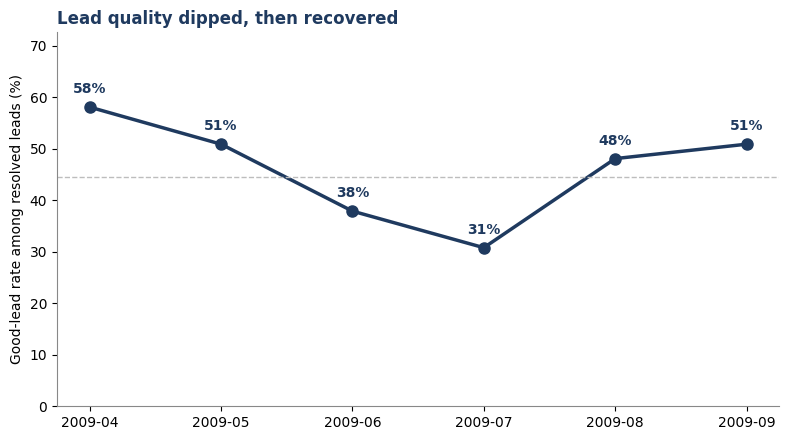

In [6]:

# %% [markdown]
# **Visualization:** the Good-lead rate among resolved leads, by month — this
# is the line that shows the dip-then-recovery pattern.

# %%
fig, ax = plt.subplots()
ax.plot(monthly.index, monthly["good_rate_%"], marker="o", color=NAVY, linewidth=2.5, markersize=8)
for x, y in zip(monthly.index, monthly["good_rate_%"]):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", fontweight="bold", color=NAVY)
ax.axhline(resolved["IsGood"].mean() * 100, color=GRAY, linestyle="--", linewidth=1)
ax.set_ylabel("Good-lead rate among resolved leads (%)")
ax.set_title("Lead quality dipped, then recovered", loc="left", fontweight="bold", color=NAVY)
ax.set_ylim(0, max(monthly["good_rate_%"]) * 1.25)
plt.tight_layout()
plt.show()


In [7]:

# %% [markdown]
# ### 1.3 Statistical test #1 — Chi-square test of independence (Month × Good/Bad)
#
# Tests whether the good/bad split is independent of month. A low p-value
# means quality genuinely differs by month (not just sampling noise).

# %%
ct_month_good = pd.crosstab(resolved["Month"], resolved["IsGood"])
chi2, p_chi2, dof, expected = stats.chi2_contingency(ct_month_good)
print(f"Chi-square = {chi2:.2f}, dof = {dof}, p = {p_chi2:.6f}")
print("--> Significant" if p_chi2 < 0.05 else "--> Not significant", "at the p < 0.05 level")


Chi-square = 30.66, dof = 5, p = 0.000011
--> Significant at the p < 0.05 level


In [8]:

# %% [markdown]
# ### 1.4 Statistical test #2 — Is the trend monotonic (straight decline/improvement)
# or curved (dip-then-recover)?
#
# Fit logistic regression of IsGood ~ time, first as a straight line, then
# adding a quadratic term, and compare with a likelihood-ratio test.

# %%
resolved["DayNum"] = (resolved["LeadCreated"] - resolved["LeadCreated"].min()).dt.days
resolved["DayNum_c"] = resolved["DayNum"] - resolved["DayNum"].mean()
resolved["DayNum_c2"] = resolved["DayNum_c"] ** 2

linear_model = smf.logit("IsGood ~ DayNum_c", data=resolved).fit(disp=0)
quad_model = smf.logit("IsGood ~ DayNum_c + DayNum_c2", data=resolved).fit(disp=0)

print("Linear time-trend model:")
print(linear_model.summary2().tables[1])
print()
print("Quadratic (curved) time-trend model:")
print(quad_model.summary2().tables[1])

lr_stat = 2 * (quad_model.llf - linear_model.llf)
lr_p = stats.chi2.sf(lr_stat, df=1)
print(f"\nLikelihood-ratio test (quadratic vs. linear): LR = {lr_stat:.2f}, p = {lr_p:.6f}")
print("--> Curved (dip-then-recover) fits significantly better than a straight trend"
      if lr_p < 0.05 else "--> No significant improvement from curvature")


Linear time-trend model:
              Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
Intercept -0.217445  0.067927 -3.201171  0.001369 -0.350578 -0.084311
DayNum_c  -0.002687  0.001400 -1.918859  0.055002 -0.005432  0.000058

Quadratic (curved) time-trend model:
              Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept -0.533566  0.097164 -5.491392  3.987789e-08 -0.724004 -0.343128
DayNum_c  -0.003394  0.001417 -2.395484  1.659842e-02 -0.006170 -0.000617
DayNum_c2  0.000133  0.000029  4.624686  3.751661e-06  0.000076  0.000189

Likelihood-ratio test (quadratic vs. linear): LR = 21.80, p = 0.000003
--> Curved (dip-then-recover) fits significantly better than a straight trend


Partner_norm  adknowledge  advertise.com  call center  google  yahoo
Month                                                               
2009-04               9.3            0.0          7.9    43.8   39.0
2009-05               5.7            0.5          7.6    44.8   41.4
2009-06               4.8            0.0          9.9    48.9   36.5
2009-07               2.1            0.0         10.3    70.5   17.1
2009-08               6.8            0.0          8.0    63.5   21.7
2009-09               5.8            0.0         10.5    52.3   31.4


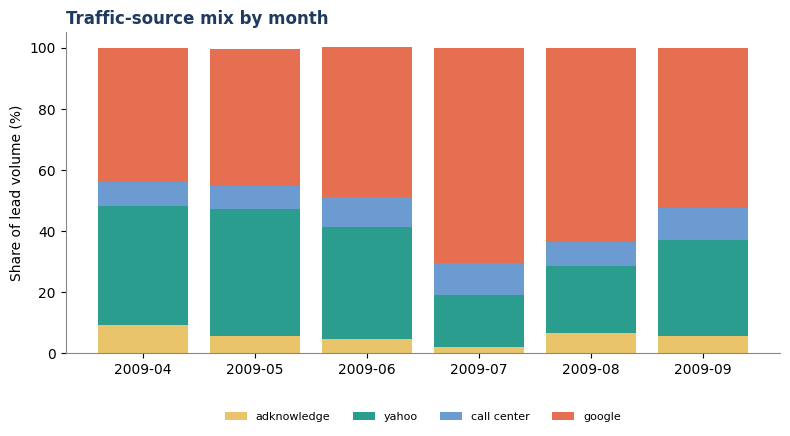

In [9]:


# %% [markdown]
# ### 1.5 What's behind the dip? Traffic-source (Partner) mix shift by month
#
# Normalize partner names (case differences in the source data) and check
# whether the volume mix across traffic sources shifted during the dip.

# %%
df["Partner_norm"] = df["Partner"].str.lower().replace({"call_center": "call center"})
partner_mix = (
    pd.crosstab(df["Month"], df["Partner_norm"], normalize="index").loc[MONTH_ORDER] * 100
).round(1)
print(partner_mix)

# %% [markdown]
# **Visualization:** traffic-source mix by month — watch Google's share spike
# in Jun-Jul, right when the good-lead rate above hit its trough.

# %%
plot_cols = [c for c in ["adknowledge", "yahoo", "call center", "google"] if c in partner_mix.columns]
fig, ax = plt.subplots()
bottom = np.zeros(len(partner_mix))
pcolors = {"adknowledge": GOLD, "yahoo": TEAL, "call center": "#6c9bd1", "google": ORANGE}
for col in plot_cols:
    ax.bar(partner_mix.index, partner_mix[col], bottom=bottom, label=col, color=pcolors[col])
    bottom += partner_mix[col].values
ax.set_ylabel("Share of lead volume (%)")
ax.set_title("Traffic-source mix by month", loc="left", fontweight="bold", color=NAVY)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

In [10]:

# %% [markdown]
# ### 1.6 Does the time pattern survive after controlling for partner & debt mix?
#
# If the curvature disappears once we control for traffic-source and debt-level
# mix, the "trend" is really just a mix-shift artifact. If it persists, there's
# a genuine residual time effect too.

# %%
DEBT_MIDPOINTS = {
    "7500-10000": 8750, "7500-15000": 11250, "10001-15000": 12500, "15001-20000": 17500,
    "20001-30000": 25000, "30001-50000": 40000, "50001-70000": 60000, "70001-90000": 80000,
    "90000-100000": 95000, "More_than_100000": 120000,
}
resolved["DebtMid_k"] = resolved["DebtLevel"].map(DEBT_MIDPOINTS) / 1000
resolved["DebtMid_k2"] = resolved["DebtMid_k"] ** 2
resolved["Partner_norm"] = resolved["Partner"].str.lower().replace({"call_center": "call center"})
resolved_ctrl = resolved[resolved["Partner_norm"] != "advertise.com"].copy()  # n=1, drop to avoid singular matrix

controlled_model = smf.logit(
    "IsGood ~ DebtMid_k + DebtMid_k2 + C(Partner_norm) + DayNum_c + DayNum_c2",
    data=resolved_ctrl,
).fit(disp=0)
print(controlled_model.summary2().tables[1])
print(f"\nPseudo R-squared: {controlled_model.prsquared:.4f}  (n={int(controlled_model.nobs)})")
print("\nIf DayNum_c2 is still significant here, the dip-and-recovery isn't fully explained")
print("by partner/debt mix alone — there's a genuine residual time effect to investigate further.")


                                   Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
Intercept                      -0.536153  0.326632 -1.641458  0.100702 -1.176340  0.104034
C(Partner_norm)[T.call center] -0.480008  0.345056 -1.391102  0.164194 -1.156304  0.196289
C(Partner_norm)[T.google]      -0.546528  0.298133 -1.833172  0.066777 -1.130857  0.037801
C(Partner_norm)[T.yahoo]       -0.384486  0.305489 -1.258594  0.208177 -0.983234  0.214261
DebtMid_k                       0.029551  0.008458  3.493852  0.000476  0.012973  0.046128
DebtMid_k2                     -0.000270  0.000072 -3.739613  0.000184 -0.000411 -0.000128
DayNum_c                       -0.002924  0.001457 -2.006798  0.044771 -0.005780 -0.000068
DayNum_c2                       0.000131  0.000029  4.473862  0.000008  0.000074  0.000189

Pseudo R-squared: 0.0368  (n=880)

If DayNum_c2 is still significant here, the dip-and-recovery isn't fully explained
by partner/debt mix alone — there's a genuine residual time ef

In [11]:


# %% [markdown]
# ---
# ## Question 2 — What drives lead quality? (Segment analysis)
#
# For each candidate driver, compute the Good-rate and Closed-rate by segment
# (on resolved leads, for statistical power) and test significance with a
# chi-square test of independence.

# %%
def segment_summary(data, col, min_n=10, sort_by="good_rate_%"):
    g = data.groupby(col).agg(n=("IsGood", "size"), good=("IsGood", "sum"), closed=("IsClosed", "sum"))
    g["good_rate_%"] = (g["good"] / g["n"] * 100).round(1)
    g["closed_rate_%"] = (g["closed"] / g["n"] * 100).round(1)
    g = g[g["n"] >= min_n].sort_values(sort_by, ascending=False)
    return g


def chi2_test(data, col, outcome="IsGood", exclude_tiny=None):
    d = data if exclude_tiny is None else data[~data[col].isin(exclude_tiny)]
    ct = pd.crosstab(d[col], d[outcome])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    return chi2, p, dof

# %% [markdown]
# ### 2.1 Debt level — inverted-U relationship

# %%
print("--- Debt level (resolved leads) ---")
print(segment_summary(resolved, "DebtLevel", min_n=5))
print()

chi2, p, dof = chi2_test(df, "DebtLevel", outcome="IsClosed")  # full population (matches headline 8.0% KPI)
print(f"Chi-square (DebtLevel vs Closed, ALL leads): chi2={chi2:.2f}, dof={dof}, p={p:.4f}")


--- Debt level (resolved leads) ---
                    n  good  closed  good_rate_%  closed_rate_%
DebtLevel                                                      
70001-90000        41    25      18         61.0           43.9
7500-15000         57    31      19         54.4           33.3
15001-20000       106    57      35         53.8           33.0
50001-70000        72    38      22         52.8           30.6
10001-15000       103    54      34         52.4           33.0
20001-30000       142    72      40         50.7           28.2
90000-100000       24    11       9         45.8           37.5
30001-50000       145    61      39         42.1           26.9
More_than_100000   51    13       7         25.5           13.7
7500-10000        140    31      22         22.1           15.7

Chi-square (DebtLevel vs Closed, ALL leads): chi2=22.99, dof=9, p=0.0062



                         n  closed  closed_rate_%
DebtBand                                         
<=10k (too low)        442      22           4.98
10k-90k (sweet spot)  2298     207           9.01
>90k (too high)        281      16           5.69


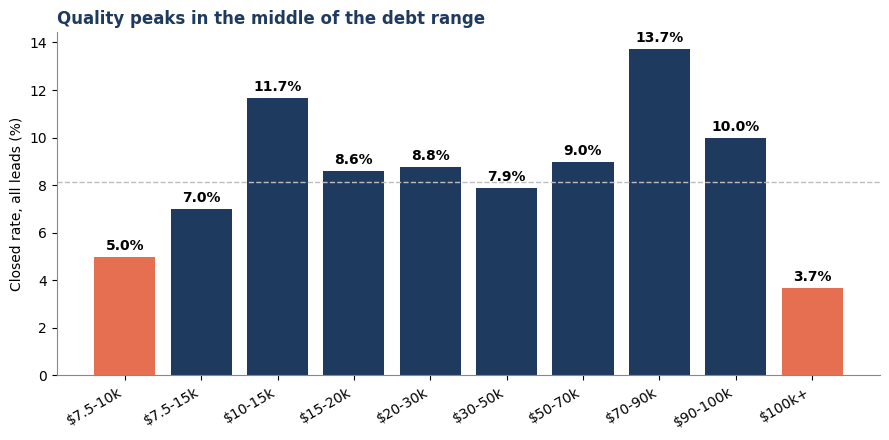

In [12]:

# Overall closed rate by debt band (low / sweet-spot / high)
df["DebtMid"] = df["DebtLevel"].map(DEBT_MIDPOINTS)
df["DebtBand"] = pd.cut(df["DebtMid"], bins=[0, 10000, 90000, 200000],
                         labels=["<=10k (too low)", "10k-90k (sweet spot)", ">90k (too high)"])
band = df.groupby("DebtBand").agg(n=("IsClosed", "size"), closed=("IsClosed", "sum"))
band["closed_rate_%"] = (band["closed"] / band["n"] * 100).round(2)
print()
print(band)

# %% [markdown]
# **Visualization:** Closed rate by debt-level bucket — the inverted-U shape.

# %%
DEBT_LABELS = {
    "7500-10000": "$7.5-10k", "7500-15000": "$7.5-15k", "10001-15000": "$10-15k",
    "15001-20000": "$15-20k", "20001-30000": "$20-30k", "30001-50000": "$30-50k",
    "50001-70000": "$50-70k", "70001-90000": "$70-90k", "90000-100000": "$90-100k",
    "More_than_100000": "$100k+",
}
debt_order = sorted(DEBT_MIDPOINTS, key=lambda k: DEBT_MIDPOINTS[k])
debt_g = df.groupby("DebtLevel").agg(n=("IsClosed", "size"), closed=("IsClosed", "sum")).loc[debt_order]
debt_g["rate"] = debt_g["closed"] / debt_g["n"] * 100
sweet_mask = [k not in ("7500-10000", "More_than_100000") for k in debt_order]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(range(len(debt_g)), debt_g["rate"], color=[NAVY if s else ORANGE for s in sweet_mask])
ax.axhline(df["IsClosed"].mean() * 100, color=GRAY, linestyle="--", linewidth=1)
for i, r in enumerate(debt_g["rate"]):
    ax.annotate(f"{r:.1f}%", (i, r), textcoords="offset points", xytext=(0, 5), ha="center", fontweight="bold")
ax.set_xticks(range(len(debt_g)))
ax.set_xticklabels([DEBT_LABELS[k] for k in debt_order], rotation=30, ha="right")
ax.set_ylabel("Closed rate, all leads (%)")
ax.set_title("Quality peaks in the middle of the debt range", loc="left", fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

In [13]:


# %% [markdown]
# ### 2.2 Traffic source (Partner)

# %%
print("--- Partner / traffic source (resolved leads) ---")
print(segment_summary(resolved, "Partner_norm"))
print()

chi2, p, dof = chi2_test(df, "Partner_norm", outcome="IsClosed", exclude_tiny=["advertise.com"])
print(f"Chi-square (Partner vs Closed, ALL leads): chi2={chi2:.2f}, dof={dof}, p={p:.4f}")

overall_rate = df["IsClosed"].mean() * 100
partner_closed = df[df["Partner_norm"] != "advertise.com"].groupby("Partner_norm").agg(
    n=("IsClosed", "size"), closed=("IsClosed", "sum")
)
partner_closed["closed_rate_%"] = (partner_closed["closed"] / partner_closed["n"] * 100).round(2)
print()
print(partner_closed.sort_values("closed_rate_%", ascending=False))
print(f"(Overall baseline: {overall_rate:.2f}%)")

--- Partner / traffic source (resolved leads) ---
                n  good  closed  good_rate_%  closed_rate_%
Partner_norm                                               
adknowledge    55    32      21         58.2           38.2
yahoo         283   136      74         48.1           26.1
google        432   180     123         41.7           28.5
call center   110    44      26         40.0           23.6

Chi-square (Partner vs Closed, ALL leads): chi2=5.56, dof=3, p=0.1353

                 n  closed  closed_rate_%
Partner_norm                             
adknowledge    171      21          12.28
call center    271      26           9.59
yahoo          958      74           7.72
google        1618     123           7.60
(Overall baseline: 8.11%)


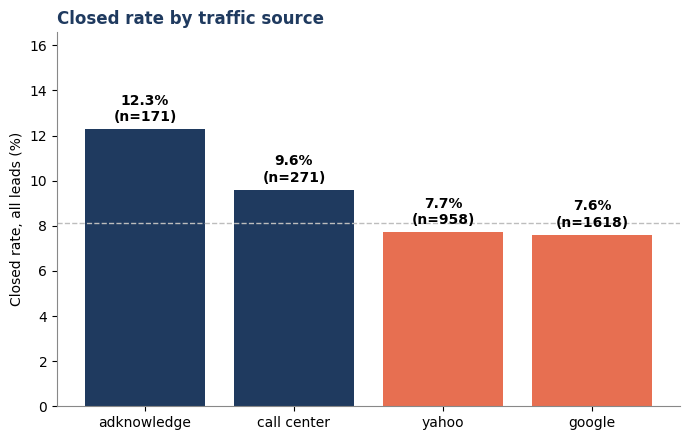

         pct_with_AddressScore  pct_with_PhoneScore      n
Month                                                     
2009-04               0.000000             0.000000  518.0
2009-05               0.000000             0.000000  580.0
2009-06               0.000000            15.763547  609.0
2009-07              74.436090            98.120301  532.0
2009-08              99.543379            99.543379  438.0
2009-09              98.546512            98.546512  344.0



In [14]:


# %% [markdown]
# **Visualization:** Closed rate by traffic source, with sample sizes labeled.

# %%
pc = partner_closed.sort_values("closed_rate_%", ascending=False)
fig, ax = plt.subplots(figsize=(7, 4.5))
bar_colors = [NAVY if r >= overall_rate else ORANGE for r in pc["closed_rate_%"]]
ax.bar(pc.index, pc["closed_rate_%"], color=bar_colors)
ax.axhline(overall_rate, color=GRAY, linestyle="--", linewidth=1)
for i, (r, n) in enumerate(zip(pc["closed_rate_%"], pc["n"])):
    ax.annotate(f"{r:.1f}%\n(n={n})", (i, r), textcoords="offset points", xytext=(0, 6), ha="center", fontweight="bold")
ax.set_ylabel("Closed rate, all leads (%)")
ax.set_title("Closed rate by traffic source", loc="left", fontweight="bold", color=NAVY)
ax.set_ylim(0, max(pc["closed_rate_%"]) * 1.35)
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 2.3 Address / Phone verification scores (only populated from July onward)

# %%
score_availability = df.groupby("Month").apply(
    lambda g: pd.Series({
        "pct_with_AddressScore": g["AddressScore"].notna().mean() * 100,
        "pct_with_PhoneScore": g["PhoneScore"].notna().mean() * 100,
        "n": len(g),
    })
)
print(score_availability)
print()

            n  closed  closed_rate_%
BothHigh                            
0         609      36           5.91
1         562      43           7.65


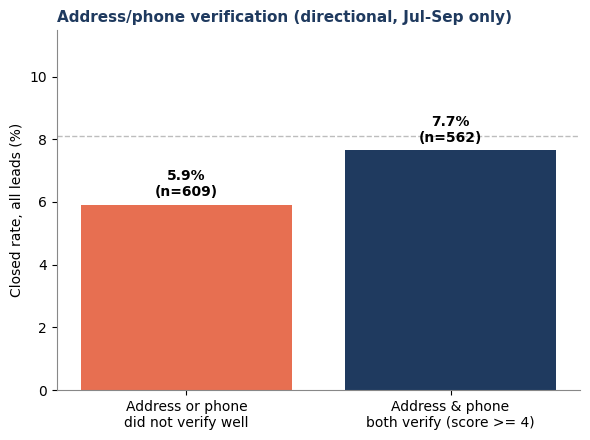

In [15]:


scored = df.dropna(subset=["AddressScore", "PhoneScore"]).copy()
scored["BothHigh"] = ((scored["AddressScore"] >= 4) & (scored["PhoneScore"] >= 4)).astype(int)
g = scored.groupby("BothHigh").agg(n=("IsClosed", "size"), closed=("IsClosed", "sum"))
g["closed_rate_%"] = (g["closed"] / g["n"] * 100).round(2)
print(g)

# %% [markdown]
# **Visualization:** Closed rate when address & phone both verify well vs. not
# (Jul–Sep subset only, since that's the only period with this data).

# %%
fig, ax = plt.subplots(figsize=(6, 4.5))
labels = ["Address or phone\ndid not verify well", "Address & phone\nboth verify (score >= 4)"]
vals = [g.loc[0, "closed_rate_%"], g.loc[1, "closed_rate_%"]]
ns = [g.loc[0, "n"], g.loc[1, "n"]]
ax.bar(labels, vals, color=[ORANGE, NAVY])
ax.axhline(df["IsClosed"].mean() * 100, color=GRAY, linestyle="--", linewidth=1)
for i, (v, n) in enumerate(zip(vals, ns)):
    ax.annotate(f"{v:.1f}%\n(n={n})", (i, v), textcoords="offset points", xytext=(0, 6), ha="center", fontweight="bold")
ax.set_ylabel("Closed rate, all leads (%)")
ax.set_title("Address/phone verification (directional, Jul-Sep only)", loc="left", fontweight="bold", color=NAVY, fontsize=11)
ax.set_ylim(0, max(vals) * 1.5)
plt.tight_layout()
plt.show()

In [16]:

chi2, p, dof = chi2_test(scored, "BothHigh", outcome="IsClosed")
print(f"\nChi-square (BothHigh score vs Closed, scored subset): chi2={chi2:.2f}, p={p:.4f}")

# Also check on the broader Good measure (more statistical power)
scored_resolved = scored[scored["IsResolved"] == 1]
chi2g, pg, dofg = chi2_test(scored_resolved, "BothHigh", outcome="IsGood")
print(f"Chi-square (BothHigh score vs Good, resolved+scored subset): chi2={chi2g:.2f}, p={pg:.4f}")

# %% [markdown]
# ### 2.4 Things that did NOT show a significant effect
#
# Form length (1-page vs 2-page), creative/branding, and online-vs-call-center
# channel — tested below on the resolved-leads Good measure.

# %%
resolved["FormPages"] = resolved["WidgetName"].apply(lambda x: "2-page" if "2DC" in x else "1-page")
resolved["CreditSolutionsDesign"] = resolved["WidgetName"].str.contains("CreditSolutions")

for col, label in [
    ("FormPages", "Form pages (1 vs 2)"),
    ("CreditSolutionsDesign", "CreditSolutions-branded design vs other"),
    ("AdvertiserCampaignName", "Branded vs generic ad copy"),
    ("PublisherCampaignName", "Call center vs online entry channel"),
]:
    chi2, p, dof = chi2_test(resolved, col, outcome="IsGood")
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"{label:45s} chi2={chi2:6.2f}  p={p:.4f}  -> {sig}")

print()
print("--- Widget-level detail (small samples — directional only) ---")
print(segment_summary(resolved, "WidgetName", min_n=15))



Chi-square (BothHigh score vs Closed, scored subset): chi2=1.14, p=0.2849
Chi-square (BothHigh score vs Good, resolved+scored subset): chi2=6.62, p=0.0101
Form pages (1 vs 2)                           chi2=  0.15  p=0.6969  -> not significant
CreditSolutions-branded design vs other       chi2=  0.06  p=0.8126  -> not significant
Branded vs generic ad copy                    chi2=  0.06  p=0.8126  -> not significant
Call center vs online entry channel           chi2=  0.88  p=0.3488  -> not significant

--- Widget-level detail (small samples — directional only) ---
                                                n  good  closed  good_rate_%  closed_rate_%
WidgetName                                                                                 
w-300250-DebtReduction1-1DC-CreditSolutions    23    18      12         78.3           52.2
w-300250-DebtReduction1-1DC-BlueMeter          18    14      13         77.8           72.2
w-300250-DebtReduction1-1DC-Head2              22    14     

Scenario                                                     n  Closed rate
Baseline — all leads                                      3021        8.11%
Debt-level qualifier ($10k-$90k only)                     2298        9.01%
AdKnowledge traffic only                                   171       12.28%
Call Center channel only                                   271        9.59%
Combined: sweet-spot debt + AdKnowledge/Call Center        344       11.34%

Target: 9.6% (a +20% relative lift on the 8.0% baseline)
  Debt-level qualifier ($10k-$90k only): 9.01% -> below target
  AdKnowledge traffic only: 12.28% -> MEETS/EXCEEDS target
  Call Center channel only: 9.59% -> below target
  Combined: sweet-spot debt + AdKnowledge/Call Center: 11.34% -> MEETS/EXCEEDS target


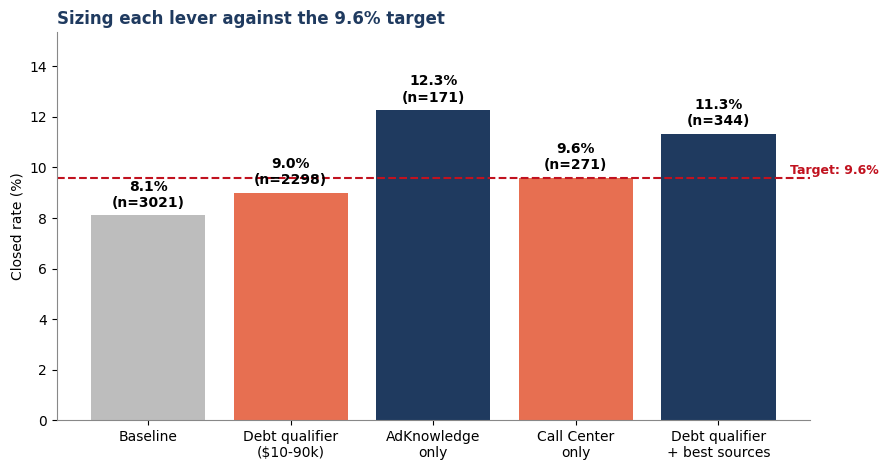

In [17]:


# %% [markdown]
# ---
# ## Question 3 — Can lead quality realistically move from 8.0% to 9.6%?
#
# Size each candidate lever directly against the historical Closed rate
# (the same metric as the 8.0% / 9.6% target in the prompt).

# %%
scenarios = []

scenarios.append(("Baseline — all leads", len(df), df["IsClosed"].mean() * 100))

sweet = df[(df["DebtMid"] > 10000) & (df["DebtMid"] <= 90000)]
scenarios.append(("Debt-level qualifier ($10k-$90k only)", len(sweet), sweet["IsClosed"].mean() * 100))

adk = df[df["Partner_norm"] == "adknowledge"]
scenarios.append(("AdKnowledge traffic only", len(adk), adk["IsClosed"].mean() * 100))

cc = df[df["Partner_norm"] == "call center"]
scenarios.append(("Call Center channel only", len(cc), cc["IsClosed"].mean() * 100))

combo = sweet[sweet["Partner_norm"].isin(["adknowledge", "call center"])]
scenarios.append(("Combined: sweet-spot debt + AdKnowledge/Call Center", len(combo), combo["IsClosed"].mean() * 100))

print(f"{'Scenario':55s} {'n':>6s} {'Closed rate':>12s}")
for label, n, rate in scenarios:
    print(f"{label:55s} {n:6d} {rate:11.2f}%")

print(f"\nTarget: 9.6% (a +20% relative lift on the 8.0% baseline)")
for label, n, rate in scenarios[1:]:
    status = "MEETS/EXCEEDS target" if rate >= 9.6 else "below target"
    print(f"  {label}: {rate:.2f}% -> {status}")

# %% [markdown]
# **Visualization:** each lever's historical Closed rate against the 9.6% target.

# %%
short_labels = ["Baseline", "Debt qualifier\n($10-90k)", "AdKnowledge\nonly", "Call Center\nonly", "Debt qualifier\n+ best sources"]
rates = [s[2] for s in scenarios]
sizes = [s[1] for s in scenarios]
fig, ax = plt.subplots(figsize=(9, 4.8))
bar_colors = [GRAY] + [NAVY if r >= 9.6 else ORANGE for r in rates[1:]]
ax.bar(short_labels, rates, color=bar_colors)
ax.axhline(9.6, color="#c1121f", linestyle="--", linewidth=1.5)
ax.text(len(rates) - 0.5, 9.6 + 0.15, "Target: 9.6%", color="#c1121f", fontweight="bold", fontsize=9)
for i, (r, n) in enumerate(zip(rates, sizes)):
    ax.annotate(f"{r:.1f}%\n(n={n})", (i, r), textcoords="offset points", xytext=(0, 6), ha="center", fontweight="bold")
ax.set_ylabel("Closed rate (%)")
ax.set_title("Sizing each lever against the 9.6% target", loc="left", fontweight="bold", color=NAVY)
ax.set_ylim(0, max(rates) * 1.25)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Summary of validated findings
#
# - Overall Closed rate ≈ 8.1%, matching the assignment's 8.0% baseline.
# - **Q1:** Month is significantly associated with quality (chi-square p < 0.001);
#   the time pattern is curved (dip then recovery), not a straight-line trend
#   (quadratic model significantly better fit, p < 0.0001), and a meaningful part
#   of it tracks a traffic-source mix shift toward Google in Jun-Jul.
# - **Q2:** Debt level (p ≈ 0.006) and traffic source are statistically supported
#   drivers; address/phone verification is a promising but data-limited signal;
#   creative/form length/channel show no significant effect.
# - **Q3:** Debt-level qualification alone gets close to the 9.6% target; combined
#   with traffic-source optimization, the historical data clears it.